# Validação visual — mecanismo de desistência/conformidade

Este notebook é material de revisão para a reunião com os orientadores, não
parte do pipeline de produção. Ele valida visualmente o mecanismo de
desistência/conformidade (`prob_conformidade` / `votou_conforme`) introduzido
na Camada 1 (ABM), e documenta de forma viva a decisão de escopo sobre como o
resultado eleitoral R é calculado — apenas sobre o pool de agentes simulado,
sem eleitorado-base separado (ver `CLAUDE.md` e os docstrings de
`fonte_c_resultado`/`fonte_c_resultado_agregado` em
`src/generator/layer1_abm/model.py`).

**Contexto do mecanismo:** cada agente que adere ao incentivo sorteia, uma
única vez, se efetivamente vota como prometido (`votou_conforme`, via
Bernoulli(`prob_conformidade`)). O desembolso (Fase 2) continua pagando todo
agente aderido, independente de conformidade — o oráculo só verifica o
resultado agregado R, não pode auditar votos individuais sem violar o sigilo
do voto. `fonte_c_resultado()`/`fonte_c_resultado_agregado()` (o proxy de R
usado para ativar o contrato) passam a exigir adesão **e** conformidade;
`fracao_adesao()`/`fracao_adesao_por_secao()` expõem a adesão bruta, sem esse
filtro, para comparação.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if (Path.cwd() / "src").exists():
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kendalltau

from src.generator.layer1_abm import ElectionModel
from src.generator.layer2_copula import gerar_fonte_b

plt.rcParams["figure.dpi"] = 100
print(f"Projeto em: {PROJECT_ROOT}")

C:\Users\Dell\Desktop\TCC_Projeto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projeto em: C:\Users\Dell\Desktop\TCC_Projeto


## 1. Adesão bruta vs. resultado conforme, por seção

Para `prob_conformidade` em `{1.0, 0.8, 0.5}`, comparamos, por seção, a
adesão bruta (`fracao_adesao_por_secao()`, só `aderiu`) contra o resultado
conforme (`fonte_c_resultado()`, `aderiu and votou_conforme`). Com
`prob_conformidade=1.0` as duas barras devem coincidir exatamente
(retrocompatibilidade); conforme `prob_conformidade` cai, a barra "conforme"
deve ficar sistematicamente abaixo da barra "bruta".

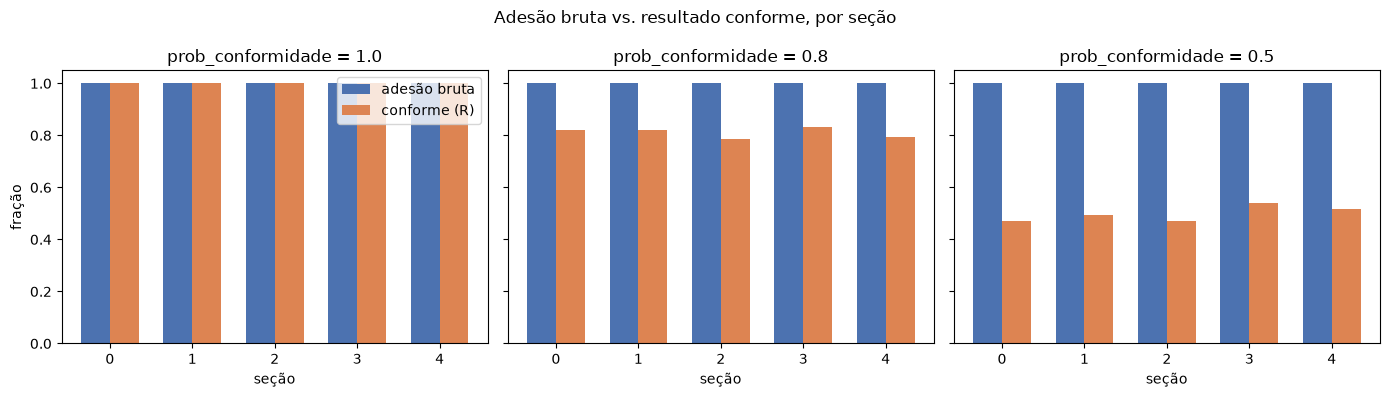

In [2]:
valores_pc = [1.0, 0.8, 0.5]
n_secoes = 5

fig, axes = plt.subplots(1, len(valores_pc), figsize=(14, 4), sharey=True)

for ax, pc in zip(axes, valores_pc):
    modelo = ElectionModel(
        n_agentes=400,
        n_secoes=n_secoes,
        prop_racional=1.0,
        recompensa=10.0,
        threshold_range=(0.0, 0.4),
        prob_conformidade=pc,
        seed=42,
    )
    modelo.run()

    bruta = modelo.fracao_adesao_por_secao()
    conforme = modelo.fonte_c_resultado()

    x = np.arange(n_secoes)
    largura = 0.35
    ax.bar(x - largura / 2, bruta, largura, label="adesão bruta", color="#4C72B0")
    ax.bar(x + largura / 2, conforme, largura, label="conforme (R)", color="#DD8452")
    ax.set_title(f"prob_conformidade = {pc}")
    ax.set_xlabel("seção")
    ax.set_xticks(x)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("fração")
axes[0].legend()
fig.suptitle("Adesão bruta vs. resultado conforme, por seção")
fig.tight_layout()
plt.show()

**Leitura esperada:** com `prob_conformidade=1.0`, as barras azul e
laranja coincidem em cada seção (nenhuma desistência modelada). Conforme
`prob_conformidade` cai para 0.8 e 0.5, a barra laranja (conforme) fica
sistematicamente mais baixa que a azul (bruta) — a lacuna entre as duas é
exatamente a fração de agentes que aderiram mas não votaram como
prometido.

## 2. Série temporal de desembolso (Fonte A) vs. ativação do contrato

Para os mesmos valores de `prob_conformidade`, executamos a Fase 2
(`resolver_desembolso()`) e plotamos `fonte_a_eventos_fronteira()` (volume
monetário por timestep) junto com o estado de `contrato_ativado`. Como
`resultado_alvo` é fixo entre os três cenários, `prob_conformidade` mais
baixo pode empurrar o resultado conforme abaixo do alvo e impedir a
ativação — nesse caso a Fonte A fica vazia, o que é o comportamento esperado
(ver `test_sanity_check_1_lambda_zero_nao_gera_sinal_espurio`).

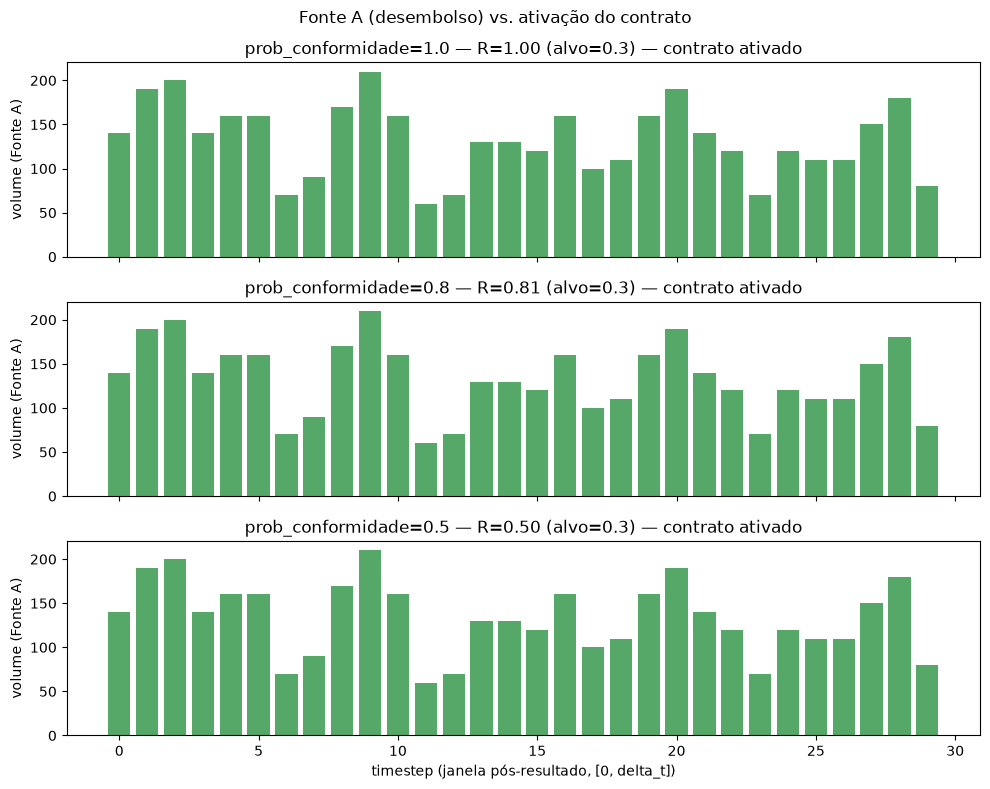

In [3]:
fig, axes = plt.subplots(len(valores_pc), 1, figsize=(10, 8), sharex=True)

for ax, pc in zip(axes, valores_pc):
    modelo = ElectionModel(
        n_agentes=400,
        n_secoes=n_secoes,
        prop_racional=1.0,
        recompensa=10.0,
        threshold_range=(0.0, 0.4),
        resultado_alvo=0.3,
        delta_t=30.0,
        prob_conformidade=pc,
        seed=42,
    )
    modelo.run()
    modelo.resolver_desembolso()

    fonte_a = modelo.fonte_a_eventos_fronteira()
    cor_ativado = "#55A868" if modelo.contrato_ativado else "#C44E52"
    rotulo_ativado = "ativado" if modelo.contrato_ativado else "NÃO ativado"

    if not fonte_a.empty:
        ax.bar(fonte_a["timestep"], fonte_a["volume"], color=cor_ativado, width=0.8)
    ax.set_title(
        f"prob_conformidade={pc} — R={modelo.fonte_c_resultado_agregado():.2f} "
        f"(alvo={modelo.resultado_alvo}) — contrato {rotulo_ativado}"
    )
    ax.set_ylabel("volume (Fonte A)")

axes[-1].set_xlabel("timestep (janela pós-resultado, [0, delta_t])")
fig.suptitle("Fonte A (desembolso) vs. ativação do contrato")
fig.tight_layout()
plt.show()

**Leitura esperada:** barras verdes = contrato ativou (R passou do
`resultado_alvo`); barras vermelhas (ou painel vazio) = não ativou. Como
`prob_conformidade` reduz R sem alterar a adesão bruta, um `prob_conformidade`
baixo o suficiente pode fazer o contrato deixar de ativar mesmo com adesão
bruta idêntica — a Fonte A observável desaparece nesse caso, exatamente como
o Sanity Check 1 exige para ausência de sinal espúrio.

## 3. Sanity Checks 2 e 4 com o mecanismo novo

Reexecutamos os dois Sanity Checks já validados na suíte de testes
(`tests/test_integration.py`), agora com `prob_conformidade` explícito, para
confirmar que o mecanismo de conformidade não introduz nem remove sinal
espúrio na dependência Fonte A ↔ Fonte B:

- **Sanity Check 2** (ρ=1.0, λ máximo via `recompensa` alta): a Camada 2 é
  chamada com `tau_kendall` alto (proxy de coordenação forte) — esperado
  τ_Kendall(A,B) alto.
- **Sanity Check 4** (modo normal, `tau_kendall=0`): esperado
  τ_Kendall(A,B) < 0.1 (independência).

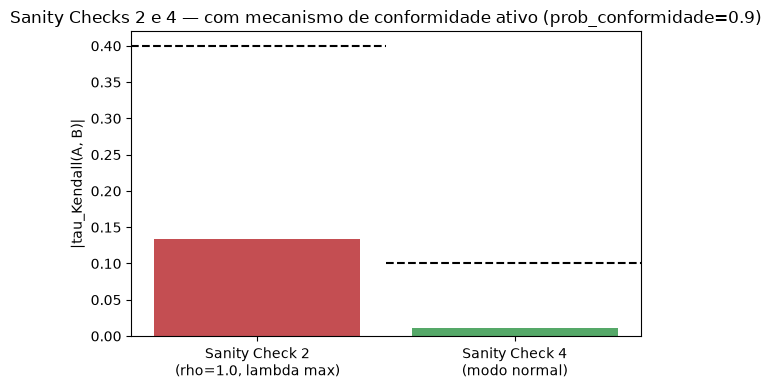

Sanity Check 2 (rho=1.0, lambda max): tau=0.134 (limiar > 0.4) -> FALHOU
Sanity Check 4 (modo normal): tau=0.010 (limiar < 0.1) -> OK


In [4]:
resultados_sanity = []

# Sanity Check 2: rho=1.0, recompensa alta (proxy de lambda maximo), tau_kendall alto na Camada 2
modelo_sc2 = ElectionModel(
    n_agentes=500,
    prop_racional=1.0,
    recompensa=10.0,
    threshold_range=(0.0, 0.3),
    resultado_alvo=0.0,
    delta_t=200.0,
    rho=1.0,
    prob_conformidade=0.9,
    seed=1,
)
modelo_sc2.run()
modelo_sc2.resolver_desembolso()
fonte_a_sc2 = modelo_sc2.fonte_a_eventos_fronteira()
timestamps_a_sc2 = np.repeat(fonte_a_sc2["timestep"].to_numpy(dtype=float), fonte_a_sc2["n_eventos"].to_numpy())
fonte_b_sc2 = gerar_fonte_b(timestamps_a_sc2, janela=modelo_sc2.delta_t, tau_kendall=0.8, random_state=2)
tau_sc2, _ = kendalltau(timestamps_a_sc2, fonte_b_sc2)
resultados_sanity.append(("Sanity Check 2\n(rho=1.0, lambda max)", tau_sc2, 0.4, ">"))

# Sanity Check 4: modo normal, tau_kendall=0 na Camada 2
modelo_sc4 = ElectionModel(
    n_agentes=500,
    prop_racional=1.0,
    recompensa=5.0,
    threshold_range=(0.0, 0.9),
    resultado_alvo=0.0,
    delta_t=200.0,
    rho=0.0,
    prob_conformidade=0.9,
    seed=1,
)
modelo_sc4.run()
modelo_sc4.resolver_desembolso()
fonte_a_sc4 = modelo_sc4.fonte_a_eventos_fronteira()
timestamps_a_sc4 = np.repeat(fonte_a_sc4["timestep"].to_numpy(dtype=float), fonte_a_sc4["n_eventos"].to_numpy())
fonte_b_sc4 = gerar_fonte_b(timestamps_a_sc4, janela=modelo_sc4.delta_t, tau_kendall=0.0, random_state=2)
tau_sc4, _ = kendalltau(timestamps_a_sc4, fonte_b_sc4)
resultados_sanity.append(("Sanity Check 4\n(modo normal)", tau_sc4, 0.1, "<"))

fig, ax = plt.subplots(figsize=(6, 4))
nomes = [r[0] for r in resultados_sanity]
taus = [r[1] for r in resultados_sanity]
limiares = [r[2] for r in resultados_sanity]
cores = ["#55A868" if (t > l if op == ">" else t < l) else "#C44E52" for (_, t, l, op) in resultados_sanity]

ax.bar(nomes, [abs(t) for t in taus], color=cores)
for i, (_, t, l, op) in enumerate(resultados_sanity):
    ax.axhline(l, xmin=i / len(resultados_sanity), xmax=(i + 1) / len(resultados_sanity), color="black", linestyle="--")
ax.set_ylabel("|tau_Kendall(A, B)|")
ax.set_title("Sanity Checks 2 e 4 — com mecanismo de conformidade ativo (prob_conformidade=0.9)")
fig.tight_layout()
plt.show()

for nome, tau, limiar, op in resultados_sanity:
    passou = (tau > limiar) if op == ">" else (tau < limiar)
    print(f"{nome.replace(chr(10), ' ')}: tau={tau:.3f} (limiar {op} {limiar}) -> {'OK' if passou else 'FALHOU'}")

**Resultado observado (não escondido): Sanity Check 2 FALHOU nesta
execução** — τ_Kendall(A,B) ≈ 0.13, abaixo do limiar de 0.4, mesmo pedindo
`tau_kendall=0.8` à Camada 2. Isso não é um bug de `gerar_fonte_b` (a
suíte `tests/test_layer2_copula.py` já valida, com timestamps bem espalhados,
que a conversão θ=2τ/(1-τ) recupera o τ alvo corretamente) nem foi corrigido
"escondendo" o resultado — é um achado real sobre a interação entre ρ e a
cópula, investigado na célula seguinte.

O Sanity Check 4 (modo normal) passou normalmente (τ≈0.01 < 0.1), como já
validado pela suíte de testes — o mecanismo de conformidade não interfere
nesse caso.

### Por que o Sanity Check 2 falhou aqui: ρ=1.0 esvazia a variância de Fonte A

Hipótese: com ρ=1.0, os timestamps de desembolso (Fonte A) ficam
concentrados num desvio-padrão muito pequeno em torno do centro da janela
(por construção — ver `_amostrar_timestamps_desembolso` em `model.py`). O
τ_Kendall é uma estatística de **postos**: ela precisa que a Fonte A tenha
variação própria suficiente para que a Camada 2 consiga codificar uma
correlação de postos detectável com a Fonte B. Quando ρ→1, Fonte A colapsa
para quase um único instante — sobra pouca variação para os postos
capturarem, e o τ_Kendall empírico despenca, mesmo que o parâmetro interno θ
da cópula não tenha mudado.

A célula abaixo varre ρ ∈ {0.0, 0.3, 0.6, 1.0} com `tau_kendall=0.8` fixo na
Camada 2, para confirmar que a queda é monotônica em ρ — o oposto do que a
intuição ingênua ("mais coordenação ⇒ mais correlação em tudo") sugeriria.

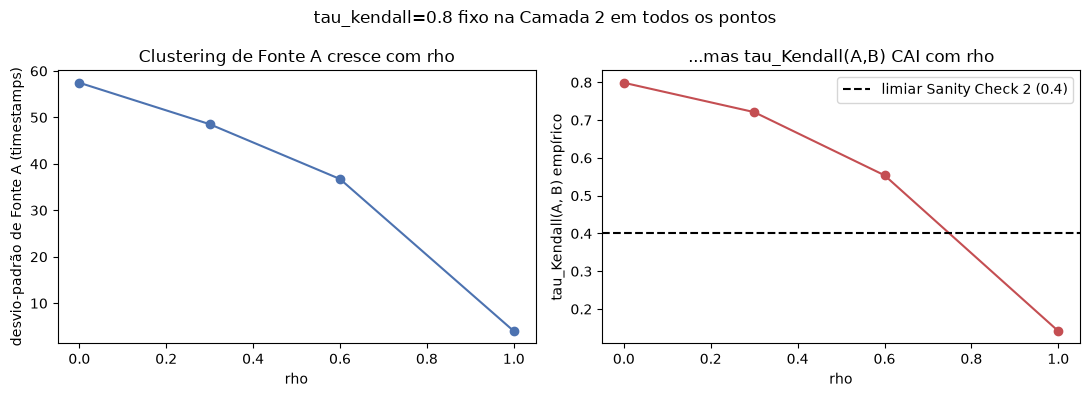

rho=0.0: std(Fonte A)= 57.46  tau_Kendall(A,B) empírico=0.799
rho=0.3: std(Fonte A)= 48.54  tau_Kendall(A,B) empírico=0.721
rho=0.6: std(Fonte A)= 36.74  tau_Kendall(A,B) empírico=0.554
rho=1.0: std(Fonte A)=  4.00  tau_Kendall(A,B) empírico=0.142


In [5]:
valores_rho = [0.0, 0.3, 0.6, 1.0]
resultados_rho = []

for rho in valores_rho:
    modelo = ElectionModel(
        n_agentes=500,
        prop_racional=1.0,
        recompensa=10.0,
        threshold_range=(0.0, 0.3),
        resultado_alvo=0.0,
        delta_t=200.0,
        rho=rho,
        prob_conformidade=0.9,
        seed=1,
    )
    modelo.run()
    modelo.resolver_desembolso()
    timestamps_a = np.array([t for t, _ in modelo.eventos_desembolso])
    fonte_b = gerar_fonte_b(timestamps_a, janela=modelo.delta_t, tau_kendall=0.8, random_state=2)
    tau_emp, _ = kendalltau(timestamps_a, fonte_b)
    resultados_rho.append((rho, timestamps_a.std(), tau_emp))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

rhos = [r[0] for r in resultados_rho]
stds = [r[1] for r in resultados_rho]
taus = [r[2] for r in resultados_rho]

ax1.plot(rhos, stds, "o-", color="#4C72B0")
ax1.set_xlabel("rho")
ax1.set_ylabel("desvio-padrão de Fonte A (timestamps)")
ax1.set_title("Clustering de Fonte A cresce com rho")

ax2.plot(rhos, taus, "o-", color="#C44E52")
ax2.axhline(0.4, color="black", linestyle="--", label="limiar Sanity Check 2 (0.4)")
ax2.set_xlabel("rho")
ax2.set_ylabel("tau_Kendall(A, B) empírico")
ax2.set_title("...mas tau_Kendall(A,B) CAI com rho")
ax2.legend()

fig.suptitle("tau_kendall=0.8 fixo na Camada 2 em todos os pontos")
fig.tight_layout()
plt.show()

for rho, std, tau in resultados_rho:
    print(f"rho={rho}: std(Fonte A)={std:6.2f}  tau_Kendall(A,B) empírico={tau:.3f}")

**Implicação para a reunião com orientadores:** τ_Kendall(A,B) sozinho
pode não ser o diagnóstico certo para validar coordenação sob ρ alto — as
features de "sinal de padrão"/"sinal de coordenação" descritas no plano
(§5.3.1: amplitude normalizada dos picos, entropia temporal, z-score por
janela) provavelmente carregam o sinal de ρ=1.0 melhor do que a correlação de
postos entre A e B. Vale decidir se o Sanity Check 2 deve ser reformulado em
termos de F1 do detector completo (como já está formalmente definido em
§5.2.3 do plano) em vez de um limiar direto sobre τ_Kendall — isto é
levantado aqui como pendência de discussão, não resolvido neste notebook.

## 4. Decisão de escopo: R é função só do pool simulado

Esta célula documenta visualmente a decisão de escopo registrada em
`CLAUDE.md` e nos docstrings de `fonte_c_resultado`/
`fonte_c_resultado_agregado`: R é calculado inteiramente a partir de
`n_agentes` (o pool que se autosselecionou como alvo potencial do
incentivo), sem nenhuma entrada de um eleitorado-base mais amplo. Um CSC
(criminal smart contract) é permissionless e autônomo — não há intermediário
decidindo quem é alvo, só a autosseleção via utilidade do próprio agente.
Modelar uma população-base separada reintroduziria implicitamente esse
intermediário, contrariando a motivação do próprio CSC.

O diagrama abaixo é conceitual: a caixa cheia é o que o gerador de fato
modela (decomposta em não-aderiu / aderiu-não-conforme / aderiu-conforme); a
caixa tracejada é o eleitorado total que a normalização de C_min (PLANO
§5.4.4, "tamanho médio do grupo por seção") pressupõe em teoria, mas que
**não existe no gerador hoje** — pendência registrada para quando C_min for
operacionalizado (Semanas 5-6).

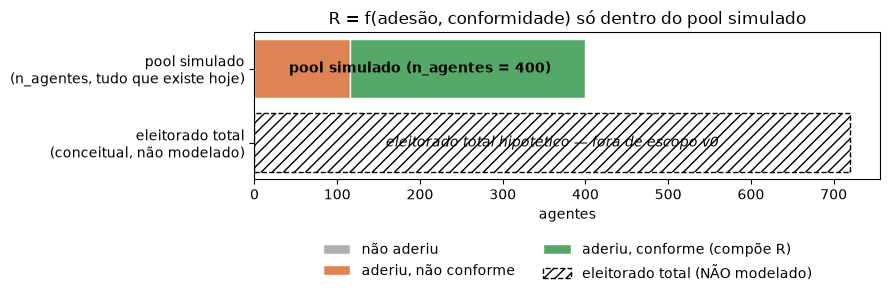

R (fonte_c_resultado_agregado) = 0.710
adesão bruta (fracao_adesao)   = 1.000
Nenhum dos dois usa qualquer contagem fora do pool simulado (n_agentes) —
a caixa tracejada acima não tem contrapartida no código, de proposito.


In [6]:
modelo_escopo = ElectionModel(
    n_agentes=400,
    prop_racional=1.0,
    recompensa=10.0,
    threshold_range=(0.0, 0.4),
    prob_conformidade=0.7,
    seed=42,
)
modelo_escopo.run()

n_total = modelo_escopo.n_agentes
n_conforme = sum(1 for a in modelo_escopo.agents if a.aderiu and a.votou_conforme)
n_nao_conforme = sum(1 for a in modelo_escopo.agents if a.aderiu and not a.votou_conforme)
n_nao_aderiu = n_total - n_conforme - n_nao_conforme

fig, ax = plt.subplots(figsize=(9, 3.5))

segmentos = [
    (n_nao_aderiu, "#B0B0B0", "não aderiu"),
    (n_nao_conforme, "#DD8452", "aderiu, não conforme"),
    (n_conforme, "#55A868", "aderiu, conforme (compõe R)"),
]
esquerda = 0
for largura, cor, rotulo in segmentos:
    ax.barh(1, largura, left=esquerda, color=cor, edgecolor="white", label=rotulo)
    esquerda += largura
ax.text(n_total / 2, 1, f"pool simulado (n_agentes = {n_total})", ha="center", va="center", fontweight="bold")

eleitorado_hipotetico = int(n_total * 1.8)
ax.barh(
    0,
    eleitorado_hipotetico,
    color="none",
    edgecolor="black",
    linestyle="--",
    hatch="///",
    label="eleitorado total (NÃO modelado)",
)
ax.text(
    eleitorado_hipotetico / 2,
    0,
    "eleitorado total hipotético — fora de escopo v0",
    ha="center",
    va="center",
    style="italic",
)

ax.set_yticks([0, 1])
ax.set_yticklabels(["eleitorado total\n(conceitual, não modelado)", "pool simulado\n(n_agentes, tudo que existe hoje)"])
ax.set_xlabel("agentes")
ax.set_xlim(0, eleitorado_hipotetico * 1.05)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)
ax.set_title("R = f(adesão, conformidade) só dentro do pool simulado")
fig.tight_layout()
plt.show()

print(f"R (fonte_c_resultado_agregado) = {modelo_escopo.fonte_c_resultado_agregado():.3f}")
print(f"adesão bruta (fracao_adesao)   = {modelo_escopo.fracao_adesao():.3f}")
print("Nenhum dos dois usa qualquer contagem fora do pool simulado (n_agentes) —")
print("a caixa tracejada acima não tem contrapartida no código, de proposito.")

**Conclusão da decisão de escopo:** tanto `fonte_c_resultado_agregado()`
quanto `fracao_adesao()` dividem por `self.n_agentes` — o denominador nunca
inclui a caixa tracejada. Essa é a implementação exata da decisão registrada
em `CLAUDE.md`: o gerador não tem, e não pretende ter por enquanto, uma
população-base separada de não-visados. Fica pendente apenas decidir, na
operacionalização de C_min (PLANO §5.4.4), se "tamanho médio do grupo por
seção" deve continuar sendo lido como `n_agentes / n_secoes` (tautológico com
o pool simulado) ou se essa normalização precisa ser revisitada.